In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Rossmon Ivan Panghulan"
student_id = "20250509"

id_num = int(student_id[-3:])
color1 = f"#{(id_num*7)%256:02x}{(id_num*3)%256:02x}{(id_num*5)%256:02x}"
color2 = f"#{(id_num*2)%256:02x}{(id_num*9)%256:02x}{(id_num*4)%256:02x}"

dataset_path = r"C:\Users\Rossmonn Ivan\Downloads\archive\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
df['year'] = df['release_year']
df['decade'] = (df['release_year'] // 10) * 10
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print("✅ Ready!")

✅ Ready!


                                     track_name                artist  duration_min
                                       Lost Boy                 Jaden      9.497883
                              I'm Getting Ready   Tasha Cobbs Leonard      8.436667
                                        Mirrors     Justin Timberlake      8.069100
What Goes Around.../...Comes Around (Interlude)     Justin Timberlake      7.476217
                             Achilles Come Down        Gang of Youths      7.035767
                           Never Let Go (Of Me)                Baltra      6.909833
          House Of Balloons / Glass Table Girls            The Weeknd      6.753550
                                           Stan                Eminem      6.735100
                                      Galvanize The Chemical Brothers      6.563550
                                    After Hours            The Weeknd      6.017100


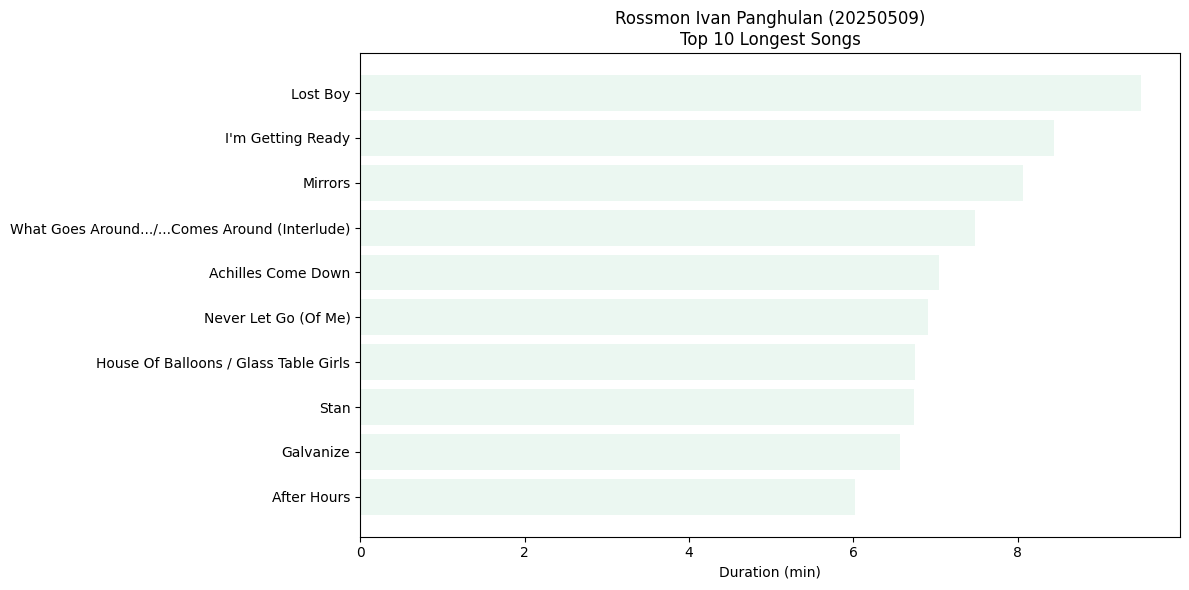

In [2]:
# ADDITIONAL EXERCISES 1
top10_longest = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

print(top10_longest.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(top10_longest['track_name'], top10_longest['duration_min'], color=color1)
plt.xlabel('Duration (min)')
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

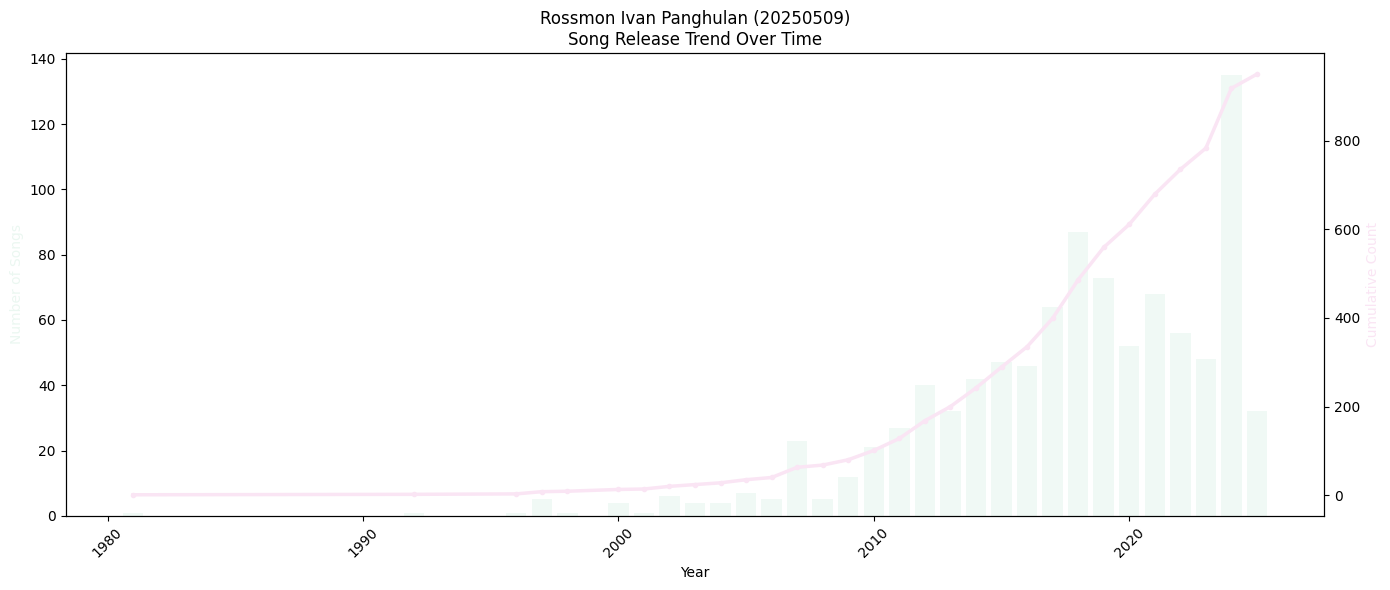

In [3]:
# ADDITIONAL EXERCISES 2
yearly_counts = df[df['release_year'] > 1900].groupby('release_year').size().reset_index(name='count')
yearly_counts['cumulative'] = yearly_counts['count'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(yearly_counts['release_year'], yearly_counts['count'], color=color1, alpha=0.7, label='Yearly Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Songs', color=color1)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(yearly_counts['release_year'], yearly_counts['cumulative'], color=color2, linewidth=2.5, marker='o', markersize=3, label='Cumulative')
ax2.set_ylabel('Cumulative Count', color=color2)

plt.title(f"{student_name} ({student_id})\nSong Release Trend Over Time")
fig.tight_layout()
plt.show()

In [4]:
# ADDITIONAL EXERCISES 3
from matplotlib.animation import FuncAnimation, PillowWriter
import os, webbrowser

years = sorted(df['release_year'].dropna().unique())
years = [y for y in years if y > 0]

fig, ax = plt.subplots(figsize=(10, 6))

def animate(i):
    ax.clear()
    year = years[i]
    df_year = df[df['release_year'] <= year]
    ax.hexbin(df_year['duration_min'], df_year['popularity'],
              gridsize=20, cmap='coolwarm', alpha=0.7)
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity')
    ax.set_title(f"{student_name} ({student_id})\nDuration vs Popularity up to {int(year)}")
    ax.set_xlim(df['duration_min'].min(), df['duration_min'].max())
    ax.set_ylim(df['popularity'].min(), df['popularity'].max())

ani = FuncAnimation(fig, animate, frames=len(years), interval=200, repeat=False)
gif_path = os.path.abspath("hexbin_density.gif")
ani.save(gif_path, writer=PillowWriter(fps=5))
print(f"✅ GIF saved at: {gif_path}")
webbrowser.open(f"file://{gif_path}")
plt.close(fig)

✅ GIF saved at: c:\Users\Rossmonn Ivan\OneDrive\Desktop\Panghulan\Lab7_Data_Visualization_Panghulan\hexbin_density.gif
